In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv # acceder a los documentos

In [6]:
with open('yocaminando.csv' , mode='r') as archivo:
    datos = csv.reader(archivo)
    encabezado = next(datos,None)
    if encabezado:
        print("primeras lineas", encabezado)
    t, latitud, longitud, altitud = [] , [] , [] , []
    for renglon in datos: #que queremos que haga con cada linea
        t.append(float(renglon[0]))
        latitud.append(float(renglon[1]))
        longitud.append(float(renglon[2]))
        altitud.append(float(renglon[3]))
t,latitud = np.array(t), np.array(latitud)
longitud, altitud = np.array(longitud), np.array(altitud)

primeras lineas ['Time (s)', 'Latitude (Â°)', 'Longitude (Â°)', 'Altitude (m)', 'Altitude WGS84 (m)', 'Speed (m/s)', 'Direction (Â°)', 'Distance (km)', 'Horizontal Accuracy (m)', 'Vertical Accuracy (m)', 'Satellites']


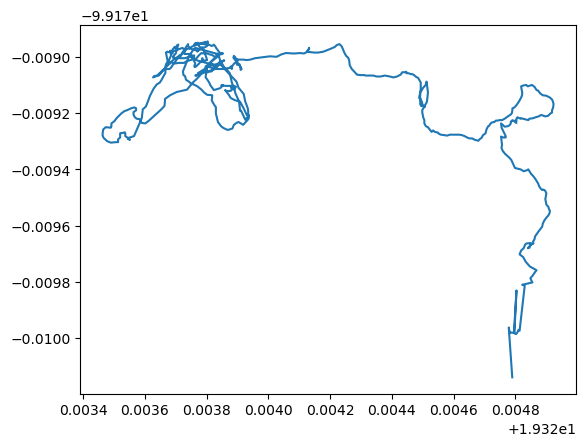

In [8]:
plt.plot(latitud,longitud)
plt.show()


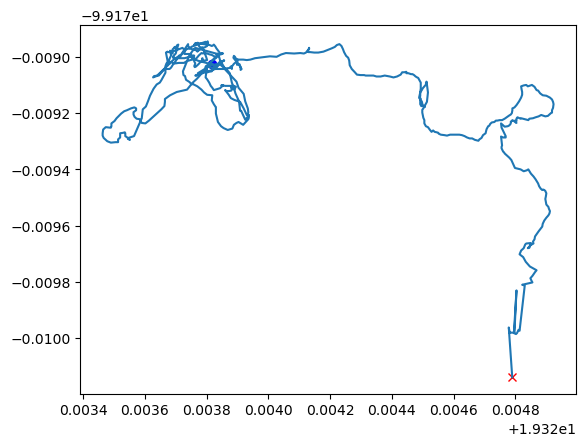

In [9]:
plt.plot(latitud[0],longitud[0],'rx')
plt.plot(latitud[-1],longitud[-1],'bo')
plt.plot(latitud,longitud)
plt.show()


-99.1801387 19.3247896
-99.179025 19.32381667


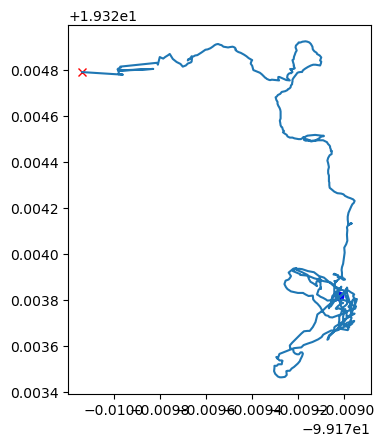

In [14]:
print(longitud[0],latitud[0])
print(longitud[-1],latitud[-1])
plt.plot(longitud[0],latitud[0],'rx')
plt.plot(longitud[-1],latitud[-1],'bo')
plt.plot(longitud,latitud)
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
def leer_csv_dat(arch):
    with open(arch.csv , mode='r') as archivo:
        datos = csv.reader(archivo)
         encabezado = next(datos,None)
    if encabezado:
        print("primeras lineas", encabezado, len(encabezado))
     t, latitud, longitud, altitud = [] , [] , [] , []
leer_csv_dat('yocaminando.csv')

In [15]:
#ejercicio
a = [[1,2],[3,4],[5,6]]
np.array(a)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [16]:
a = [[1,2],[3,4],[5,6]]
a = np.array(a)
a[:,0]   #fin del ejercicio

array([1, 3, 5])

In [19]:
def leer_csv_dat(arch):
    with open(arch , mode='r') as archivo:
        datos = csv.reader(archivo)
        encabezado = next(datos,None)
        if encabezado:
            print("primeras lineas", encabezado)
        mat_dat = []
        for renglon in datos:
            mat_dat.append(renglon[:4])
    mat_dat = np.array(mat_dat) # convertir en arreglo numerico
    # mat_dat[i,j] i renglon y j es el columna
    return mat_dat
mis_datos = leer_csv_dat('yocaminando.csv')
mis_datos[0:,]

primeras lineas ['Time (s)', 'Latitude (Â°)', 'Longitude (Â°)', 'Altitude (m)', 'Altitude WGS84 (m)', 'Speed (m/s)', 'Direction (Â°)', 'Distance (km)', 'Horizontal Accuracy (m)', 'Vertical Accuracy (m)', 'Satellites']


array([['3.088945730E-1', '1.932478960E1', '-9.918013870E1',
        '2.287553842E3'],
       ['1.973619615E0', '1.932478960E1', '-9.918013870E1',
        '2.287553842E3'],
       ['1.043589457E1', '1.932477833E1', '-9.917996167E1',
        '2.329853322E3'],
       ...,
       ['8.353558946E2', '1.932382333E1', '-9.917903333E1',
        '2.295253645E3'],
       ['8.363558946E2', '1.932382167E1', '-9.917902833E1',
        '2.295253638E3'],
       ['8.373558946E2', '1.932381667E1', '-9.917902500E1',
        '2.295153643E3']], shape=(829, 4), dtype='<U14')

In [23]:
def leer_csv_dat(arch):
    with open(arch , mode='r') as archivo:
        datos = csv.reader(archivo)
        encabezado = next(datos,None)
        #if encabezado:
        #    print("primeras lineas", encabezado)
        mat_dat = []
        for renglon in datos:
            mat_dat.append(renglon[:4])
    mat_dat = np.array(mat_dat) # convertir en arreglo numerico
    # mat_dat[i,j] i renglon y j es el columna
    return mat_dat

In [24]:
mis_datos = leer_csv_dat('yocaminando.csv')
len(mis_datos)
#mis_datos = mis_datos.reshape(len(mis_datos[:,0],4))

829

In [34]:
def leer_csv_dat(arch):
    with open('yocaminando.csv' , mode='r') as archivo:
        datos = csv.reader(archivo)
        encabezado = next(datos,None)
        #if encabezado:
        #    print("primeras lineas", encabezado)
        mat_dat = []
        for renglon in datos:
            mat_dat.append(renglon[:4])
    dat = np.zeros( (len(mat_dat),4) )
    # i renglon y j columna
    for i in range(len(mat_dat)):
        for j in range(4):
            dat[i,j] = mat_dat[i][j]        
    return dat

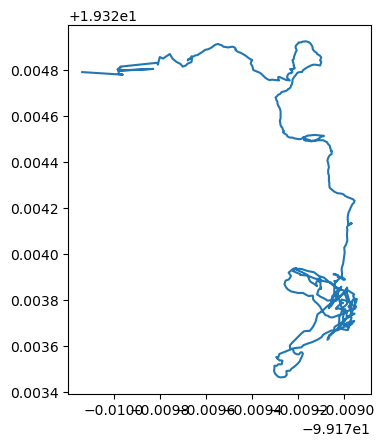

In [35]:
mat = leer_csv_dat('yocaminando.csv')
plt.plot(mat[:,2],mat[:,1])
plt.gca().set_aspect('equal')
plt.show()

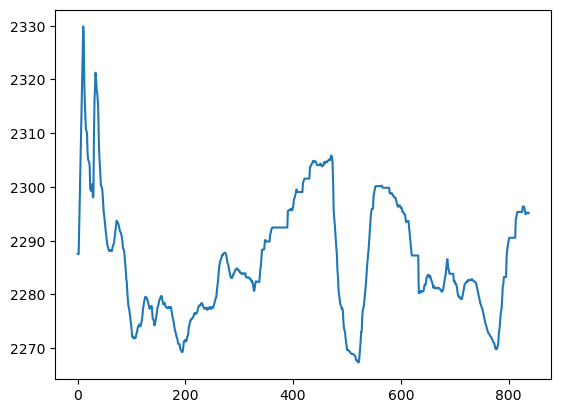

In [37]:
x = mat[:,3]*np.cos(mat[:,1])*np.cos(mat[:,2])# son coordenadadas en gps
y = mat[:,3]*np.cos(mat[:,1])*np.sin(mat[:,2])
z = mat[:,3]*np.sin(mat[:,1])
d = np.sqrt(x**2 + y**2 + z**2)
plt.plot(mat[:,0],d)
plt.show()

6718349.273966918


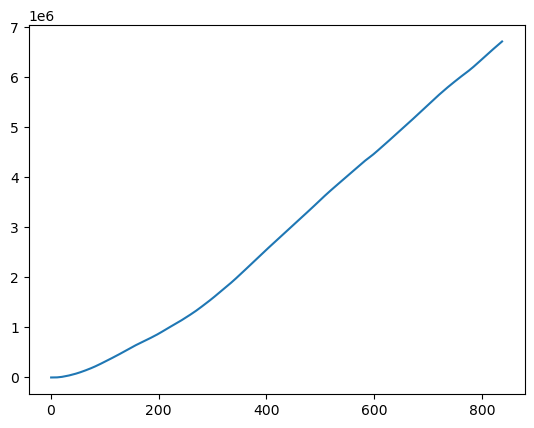

In [43]:
# con el radio de la tierra 
RT = 6731000
t = mat[:,0]
x = (RT + mat[:,3])*np.cos(mat[:,1])*np.cos(mat[:,2])# son coordenadadas en gps
y = (RT + mat[:,3])*np.cos(mat[:,1])*np.sin(mat[:,2])
z = (RT + mat[:,3])*np.sin(mat[:,1])
dist_acumulada = np.zeros( len(mat[:,1]) )
for i in range(len(mat[:,1])-1):
     dist_acumulada[i+1] = dist_acumulada[i] + np.sqrt( (x[i+1]-x[1])**2 + (y[i+1]-y[1])**2 + (z[i+1]-z[1])**2  )
print(dist_acumulada[-1])
plt.plot(t,dist_acumulada)
plt.show()